In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [6]:
from xgboost import XGBClassifier

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [8]:
import joblib

In [9]:
df = pd.read_csv('heart.csv')

In [ ]:
df.head() # PRINT FIRST 5 ROWS

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
df.shape

(1025, 14)

In [ ]:
df.isnull().sum() #check for missing vlaues

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
df.dtypes # PRINT THE DATA TYPES


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [15]:
df.describe() # STATISTICAL SUMMARY

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


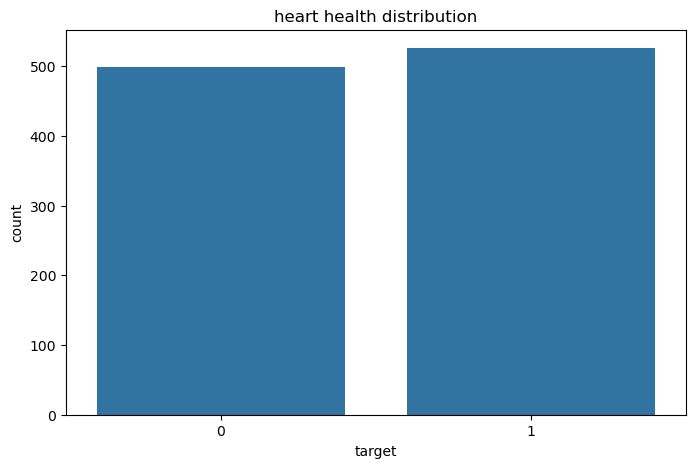

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='target',data = df)
plt.title("heart health distribution")
plt.show()

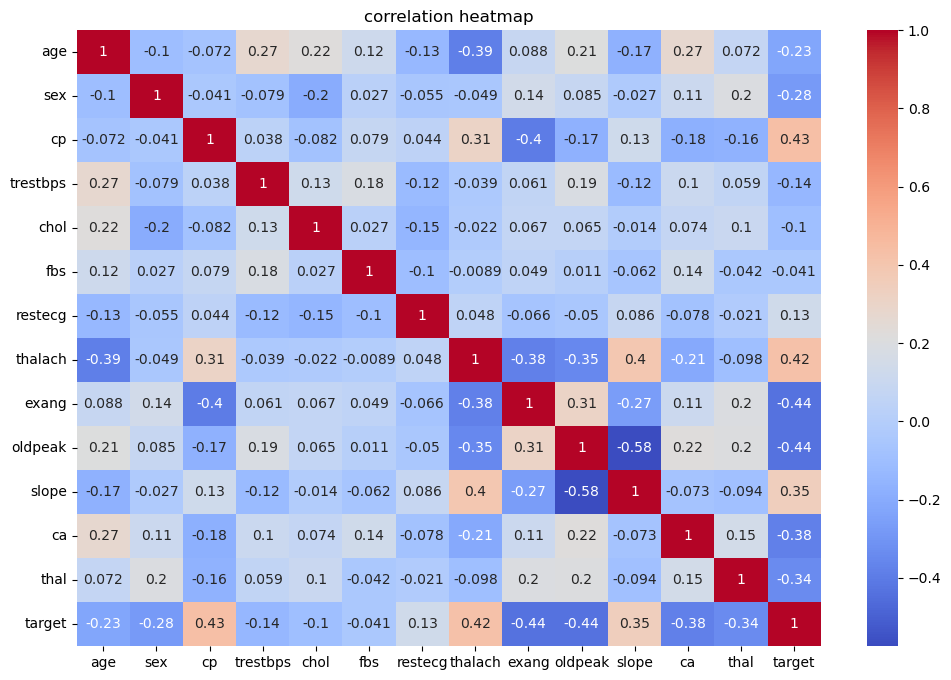

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [18]:
# FEATURES AND TARGET
X = df.drop('target',axis=1)
y = df['target']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
def evaluate_model(name, model, X_test, y_test):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc,4))

    print("\nClassification Report")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return roc



Logistic Regression
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1 Score : 0.8312
ROC AUC  : 0.9298

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



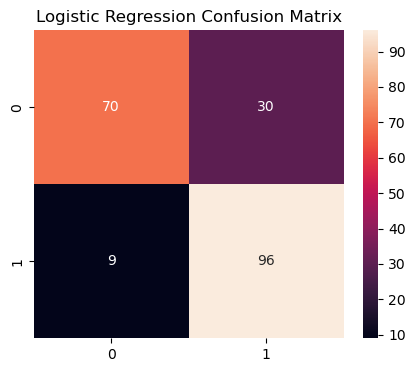

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(
    X_train_scaled,
    y_train
)

lr_auc = evaluate_model(
    "Logistic Regression",
    lr,
    X_test_scaled,
    y_test
)



Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



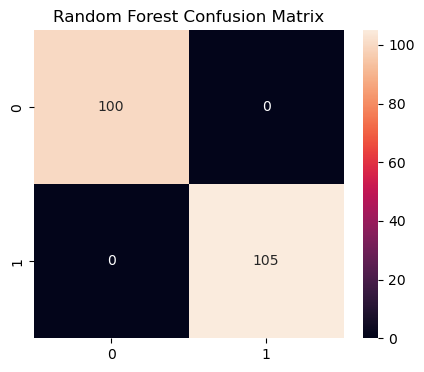

In [23]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_auc = evaluate_model(
    "Random Forest",
    rf,
    X_test,
    y_test
)


XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



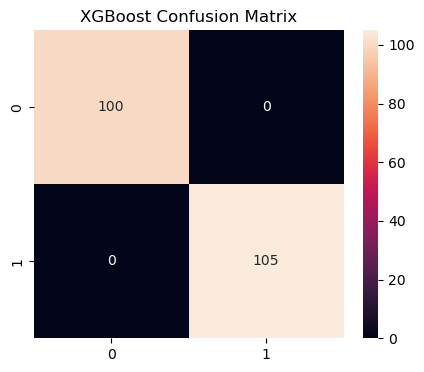

In [24]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

xgb_auc = evaluate_model(
    "XGBoost",
    xgb,
    X_test,
    y_test
)


In [25]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC":[
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

print("\nMODEL COMPARISON")
print(results)


MODEL COMPARISON
                 Model  ROC_AUC
0  Logistic Regression  0.92981
1        Random Forest  1.00000
2              XGBoost  1.00000


In [26]:
best_model_name = results.sort_values(
    by="ROC_AUC",
    ascending=False
).iloc[0]["Model"]

print("\nBEST MODEL:", best_model_name)



BEST MODEL: Random Forest


In [27]:
importance = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTOP FEATURES")
print(feature_df)



TOP FEATURES
     Feature  Importance
2         cp    0.150118
11        ca    0.115404
7    thalach    0.110806
9    oldpeak    0.105386
12      thal    0.098845
0        age    0.090121
4       chol    0.077463
8      exang    0.075101
3   trestbps    0.071527
10     slope    0.044184
1        sex    0.031292
6    restecg    0.019423
5        fbs    0.010329


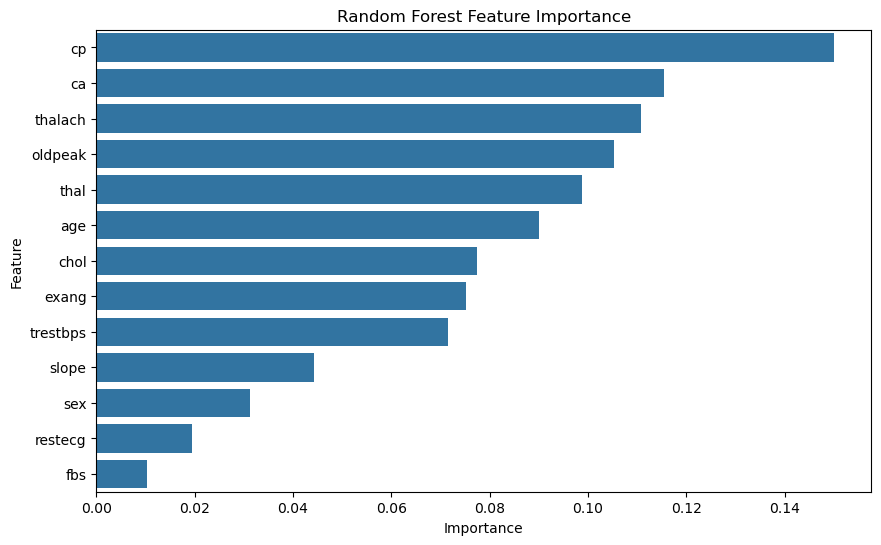

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()


In [29]:
joblib.dump(rf, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nMODEL SAVED SUCCESSFULLY")



MODEL SAVED SUCCESSFULLY


In [30]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)
probability = rf.predict_proba(sample)

print("\nSAMPLE PREDICTION")
print("Prediction:", prediction[0])
print("Probability:", probability[0][1])

print("\nPROJECT COMPLETED SUCCESSFULLY")


SAMPLE PREDICTION
Prediction: 0
Probability: 0.010193541102077689

PROJECT COMPLETED SUCCESSFULLY


In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross Validation ROC-AUC Scores:")
print(cv_scores)

print("Average ROC-AUC:")
print(cv_scores.mean())

Cross Validation ROC-AUC Scores:
[1.         1.         1.         1.         0.99885649]
Average ROC-AUC:
0.9997712978845055


In [32]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

best_rf = grid.best_estimator_

Best Parameters
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


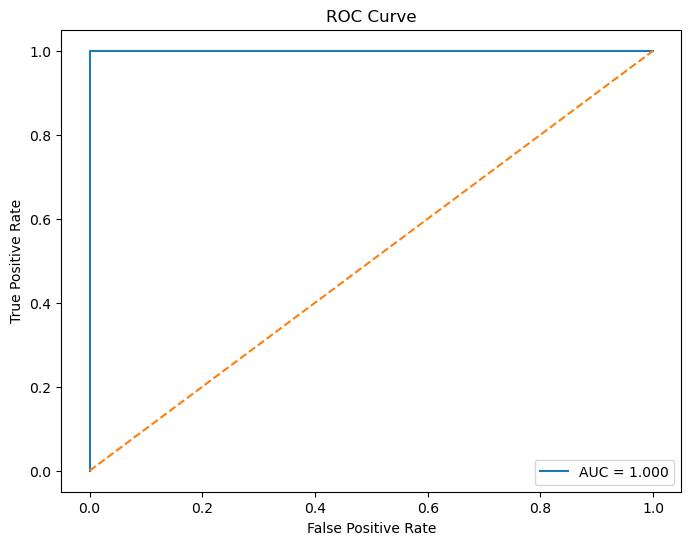

In [33]:
from sklearn.metrics import roc_curve

prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, prob):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

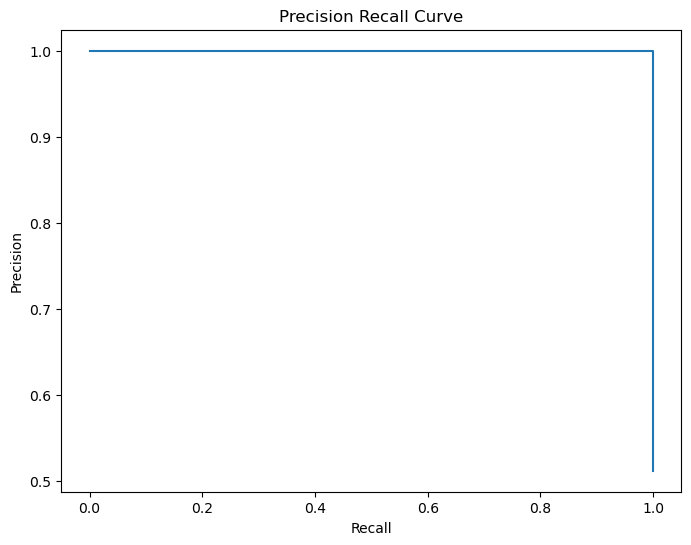

In [34]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.show()

In [35]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]
Note: you may need to restart the kernel to use updated packages.


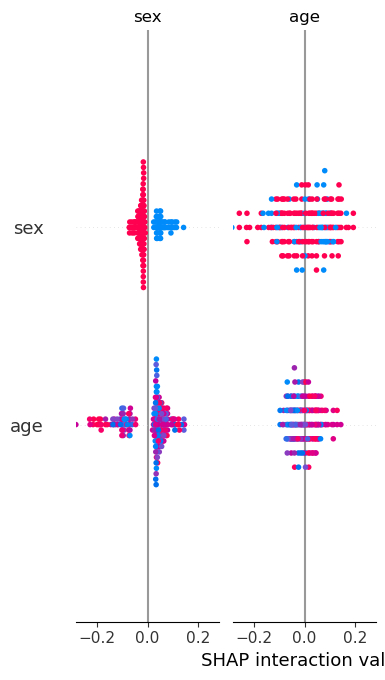

In [36]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [37]:
def risk_category(prob):

    if prob < 0.25:
        return "Low Risk"

    elif prob < 0.50:
        return "Moderate Risk"

    elif prob < 0.75:
        return "High Risk"

    else:
        return "Critical Risk"

In [38]:
import sqlite3

conn = sqlite3.connect(
    "heart_predictions.db"
)

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS predictions(
id INTEGER PRIMARY KEY AUTOINCREMENT,
prediction_date TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
probability REAL,
risk_level TEXT
)
""")

conn.commit()

In [39]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [40]:
# app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load(
    "heart_model.pkl"
)

st.title(
    "Heart Disease Risk Analytics Platform"
)

age = st.number_input(
    "Age",
    20,
    100,
    50
)

sex = st.selectbox(
    "Sex",
    [0,1]
)

cp = st.selectbox(
    "Chest Pain Type",
    [0,1,2,3]
)

trestbps = st.number_input(
    "Blood Pressure",
    80,
    250,
    120
)

chol = st.number_input(
    "Cholesterol",
    100,
    600,
    200
)

if st.button("Predict"):

    patient = pd.DataFrame({
        "age":[age],
        "sex":[sex],
        "cp":[cp],
        "trestbps":[trestbps],
        "chol":[chol]
    })

    st.write(
        model.predict(patient)
    )

2026-06-11 18:50:02.191 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.234 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-11 18:50:02.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 18:50:02.237 Session state does not

Exception ignored in: <function ResourceTracker.__del__ at 0x1076d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1112b9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104d4dbc0>
Traceback (most recent call last